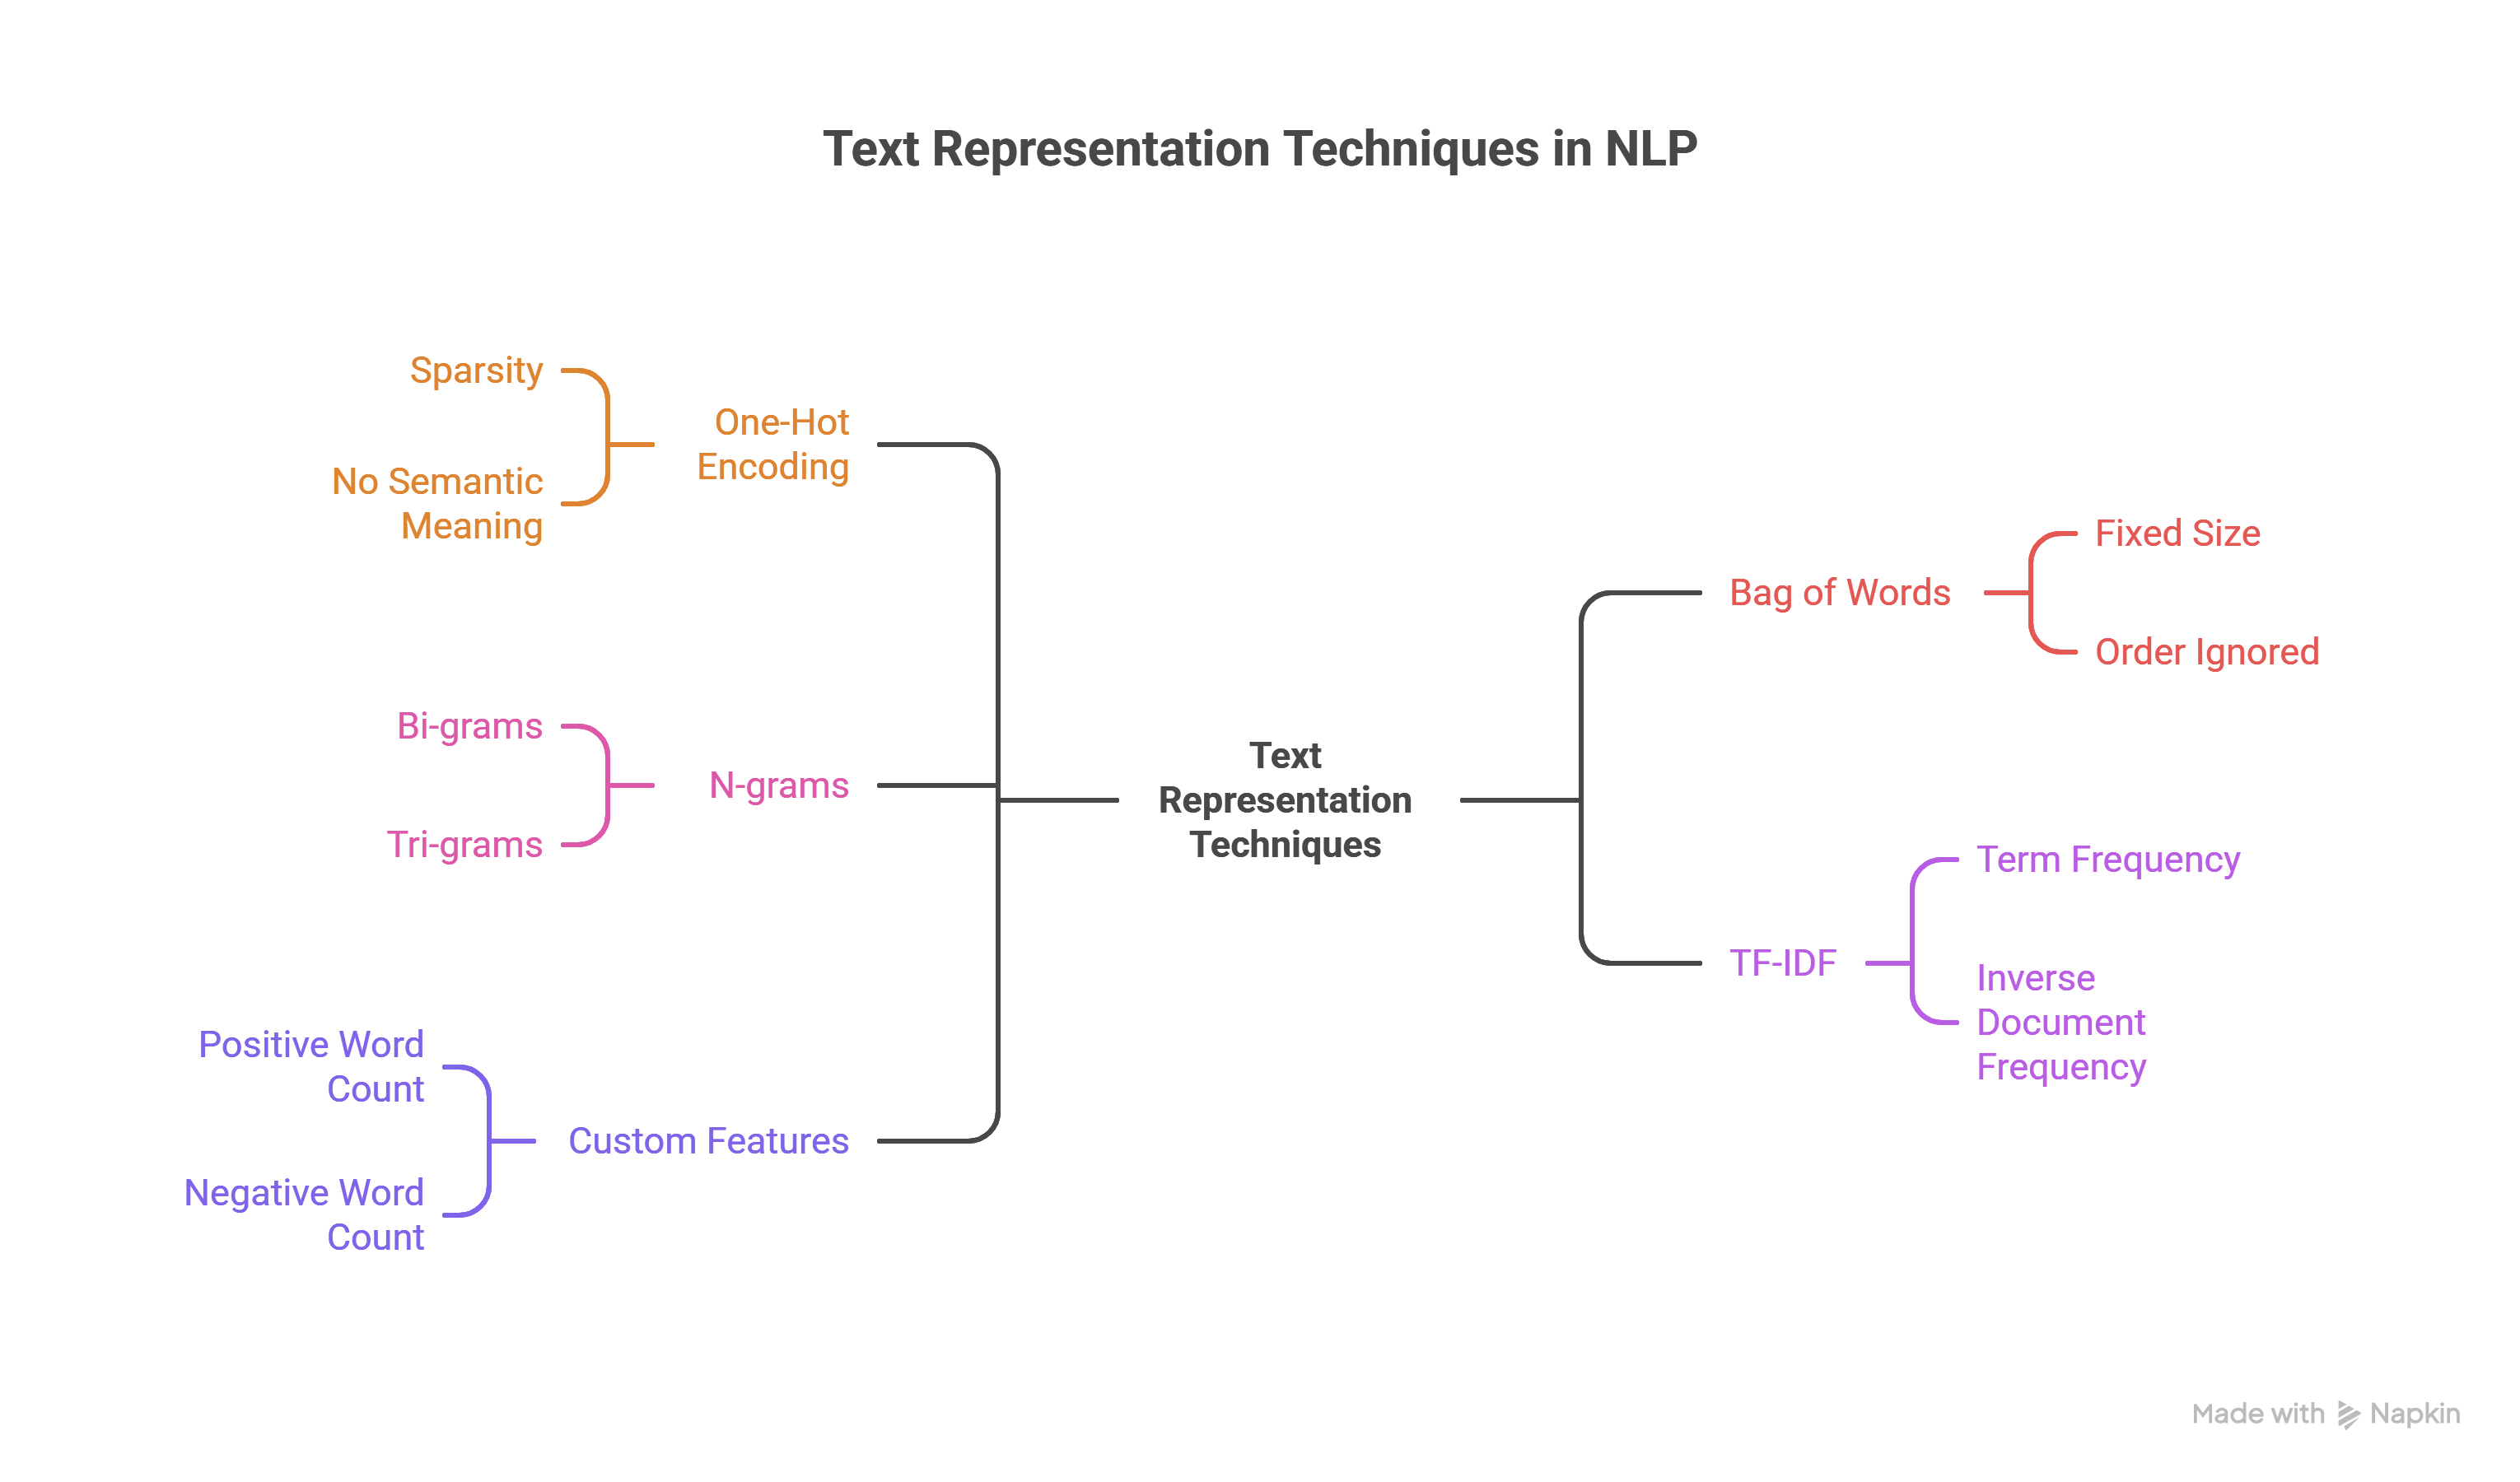



### Introduction and Core Concepts

The primary goal of text representation is to convert unstructured text data into numbers because ML algorithms rely solely on mathematical inputs, not human language. If the features provided to the ML algorithm are poor, the resulting output will also be poor ("Garbage in, garbage out").

A crucial requirement for effective text representation is that the resulting numbers must accurately convey the **semantic meaning** (the hidden meaning) of the text.

Before discussing the techniques, the source defines four key terms used throughout text vectorization:

1.  **Corpus (C):** The combination of all words in the entire dataset, including repetitions.
2.  **Vocabulary (V):** The collection of all unique words that exist within the corpus.
3.  **Document (D):** Each individual piece of text, such as a single review or sentence.
4.  **Word (W):** An individual term within a document.

The source covers five main approaches: One-Hot Encoding, Bag of Words (BoW), N-grams, TF-IDF, and Custom Features.

### 1. One-Hot Encoding

One-Hot Encoding is described as a basic, intuitive, and easy-to-implement technique.

*   **Mechanism:** Every word in a document is converted into a vector whose dimension matches the size of the vocabulary (V). In this vector, only the index corresponding to the specific word is marked as '1', and all other indices are '0'.

*   **Disadvantages (Why it is not used today):** One-Hot Encoding has several major flaws:
    *   **Sparsity:** When the vocabulary is large (e.g., 50,000 unique words), the resulting vectors are extremely large and mostly filled with zeros (sparse arrays), which are difficult to handle.
    *   **Not Fixed Size:** If documents have varying numbers of words, the resulting input array sizes change, preventing ML algorithms from training effectively, as they typically require a fixed input size.
    *   **Out of Vocabulary (OOV):** If a word appears during prediction that was not in the training vocabulary, it cannot be represented numerically.
    *   **No Semantic Meaning Capture:** Because each word vector only has one '1', all words are represented as being equidistant in the vector space, meaning the technique fails to capture the inherent semantic relationship (or similarity) between related words (like "walk" and "run").

### 2. Bag of Words (BoW)

Bag of Words is a highly famous and frequently used technique, particularly effective for **Text Classification** problems.

*   **Mechanism:** BoW generates a vector for each document, where the dimension of the vector is equal to the size of the vocabulary. Each element in the document's vector records the **frequency (count)** of how many times the corresponding vocabulary word appears in that document.
*   **Intuition:** The core idea is that documents belonging to the same category will use similar types of words with similar frequencies.
*   **Word Order:** Crucially, BoW completely **ignores the order** of words in a sentence; it only cares about which words occur and their frequency.

*   **Advantages over One-Hot Encoding:**
    *   BoW solves the "Not Fixed Size" problem because every document is represented by a vector of fixed length (V), regardless of the document's length.
    *   It handles OOV better than One-Hot Encoding because new words not in the vocabulary are simply ignored, though this results in information loss.
    *   It captures semantic relationships slightly better than One-Hot Encoding by placing similar sentences closer together in the vector space.

*   **Disadvantages:**
    *   **Sparsity:** BoW still suffers from the sparsity issue, especially with large vocabularies.
    *   **Order Ignored:** Ignoring word order prevents the model from fully understanding the context and meaning of the text.
    *   **Negation Failure:** The technique struggles when dealing with negations (e.g., "good movie" versus "not good movie"). Since most words and frequencies remain similar, the vectors are placed close together, failing to capture the completely opposite sentiment.

### 3. N-grams (Bag of N-grams)

N-grams are used to solve the issues arising from BoW's failure to recognize word order, especially concerning negation.

*   **Mechanism:** Instead of building the vocabulary from single words (Uni-grams, which is equivalent to BoW), N-grams create tokens by combining multiple **continuous** words.
    *   **Bi-grams (N=2):** Uses pairs of consecutive words (e.g., "People watch").
    *   **Tri-grams (N=3):** Uses sequences of three continuous words.
*   **Benefit:** By treating phrases like "is not" or "not good" as a single token, N-grams enable the capture of more complex contextual and semantic meaning, ensuring that sentences with opposite meanings are represented as being farther apart in the vector space.
*   **Disadvantage:** As N increases (e.g., from Uni-gram to Bi-gram), the dimension (size) of the vocabulary increases significantly, which slows down the model training and increases computational complexity.

### 4. TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF is distinct because, unlike BoW or N-grams, which treat all tokens with equal importance (equal weight), TF-IDF assigns **different weights** to different words.

*   **Core Logic:** The technique prioritizes words that appear very frequently within a specific document (high importance *to that document*) but appear rarely across the entire corpus (high importance *to distinguish that document*).
*   **Calculation:** The weight is calculated by multiplying Term Frequency (TF) and Inverse Document Frequency (IDF).

#### Term Frequency (TF)
*   **Purpose:** Measures how often a word occurs in a specific document.
*   **Formula:** $\text{Number of occurrences of the term in Document D} / \text{Total number of terms in Document D}$.

#### Inverse Document Frequency (IDF)
*   **Purpose:** Measures how rare a word is across the entire corpus.
*   **Formula (Standard):** $\text{Log}(\text{Total number of documents in the corpus} / \text{Number of documents containing the term T})$.
*   **IDF Insight:** Words common across all documents (like "the") have a low IDF (close to zero), meaning they receive a lower weight. Rare words have a high IDF.
*   **Role of Log:** Logarithm is applied to normalize the scores and prevent very rare terms from getting excessively large IDF scores that would overshadow the TF score, ensuring both frequency within the document (TF) and rarity across the corpus (IDF) contribute to the final weight.

*   **Application:** TF-IDF is highly beneficial in **Information Retrieval Systems**, such as search engines.
*   **Disadvantages:** It still suffers from **sparsity**, the **OOV problem**, high dimensionality, and fails to capture the semantic relationship between synonyms (e.g., "beautiful" and "gorgeous").

### 5. Custom Features (Handcrafted Features)

Custom or Handcrafted Features are features created by an NLP engineer based on domain knowledge of the specific problem being solved.

*   **Examples (for Sentiment Analysis):** Counting the number of positive words, the number of negative words, the ratio of positive to negative words, or character counts.
*   **Hybrid Approach:** In most real-world scenarios, standard features derived from techniques like BoW or TF-IDF are combined with Custom Features to create "Hybrid Features" that are fed into the ML model.

